# DINO: Aprendizaje Auto-Supervisado para Vision

DINOv2 y DINOv3 son modelos que aprenden features visuales sin necesidad de etiquetas. Aprenden mirando millones de imagenes y encontrando patrones por si mismos.

**Para que sirve:**
- Extraer features (embeddings) de imagenes
- Encontrar similitudes entre imagenes o regiones
- Servir como base (backbone) para otros modelos
- Clustering y busqueda de imagenes similares

La ventaja: no necesita datos etiquetados, aprende conceptos generales de manera automatica.

## Configuracion e Imports

In [1]:
import torch
import transformers
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import cv2
import requests
from io import BytesIO
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch version: {torch.__version__}, usando: {device}")
print(f"transformers version: {transformers.__version__}")

torch version: 2.7.1+cu128, usando: cuda
transformers version: 4.57.1


## Carga del Modelo DINOv2

Usamos `facebook/dinov2-base` que es la version de tamaño medio. Hay versiones small, base, large y giant segun necesites mas precision o velocidad.

In [41]:
# model_name = "facebook/dinov2-base" #DINOV2
model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m" #DINOv3

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

print(f"Modelo DINO cargado: {model_name}")
print(f"Dimension de embeddings: {model.config.hidden_size}")

Modelo DINO cargado: facebook/dinov3-vitb16-pretrain-lvd1689m
Dimension de embeddings: 768


## Carga de Imagenes de Ejemplo

In [55]:
# Cargar imagenes desde GitHub
url_cars = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/cars.jpg"
image_cars = Image.open(BytesIO(requests.get(url_cars).content)).convert("RGB")

url_person_cars = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_cars.jpg"
image_person_cars = Image.open(BytesIO(requests.get(url_person_cars).content)).convert("RGB")

url_person_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_dog.jpg"
image_person_dog = Image.open(BytesIO(requests.get(url_person_dog).content)).convert("RGB")

url_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/dog.jpg"
image_dog = Image.open(BytesIO(requests.get(url_dog).content)).convert("RGB")

url_fruits = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/fruits.jpg"
image_fruits = Image.open(BytesIO(requests.get(url_fruits).content)).convert("RGB")

url_bananas = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/bananas.jpg"
image_bananas = Image.open(BytesIO(requests.get(url_bananas).content)).convert("RGB")

url_person_banana = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_banana.jpg"
image_person_banana = Image.open(BytesIO(requests.get(url_person_banana).content)).convert("RGB")
print("Imagenes cargadas")

Imagenes cargadas


## Extraer Embeddings de una Imagen

DINOv2 genera un embedding (vector numerico) que representa el contenido de la imagen. Imagenes similares tendran embeddings similares.

El modelo divide la imagen en patches (trozos) y genera un embedding para cada uno, mas un token especial `[CLS]` que representa la imagen completa.

In [50]:
def extract_embeddings(image):
    """Extrae embeddings de imagen usando DINOv2/v3"""    
    inputs = processor(images=image, return_tensors="pt", do_resize=False, do_center_crop=False).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # CLS token: representa la imagen completa
    cls_embedding = outputs.last_hidden_state[0, 0, :].cpu().numpy()
    
    # Patch tokens: cada region de la imagen
    patch_embeddings = outputs.last_hidden_state[0, 1:, :].cpu().numpy()
    
    print(f"Embedding global (CLS): {cls_embedding.shape}, Patch embeddings: {patch_embeddings.shape}")
    
    return cls_embedding, patch_embeddings

cls_emb, patch_emb = extract_embeddings(image_cars)

Embedding global (CLS): (768,), Patch embeddings: (2254, 768)


## Similitud entre Imagenes

Podemos calcular la similitud entre dos imagenes usando sus embeddings. La similitud coseno nos dice que tan parecidas son (1 = identicas, 0 = no relacionadas).

Embedding global (CLS): (768,), Patch embeddings: (1988, 768)
Embedding global (CLS): (768,), Patch embeddings: (1988, 768)

Similitud coseno: 1.000
Parecido: 100.0%
  (0% = nada que ver | 50% = algo relacionado | 100% = idénticas)


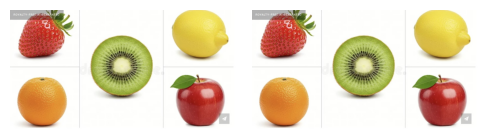

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)
Embedding global (CLS): (768,), Patch embeddings: (3140, 768)

Similitud coseno: -0.128
Parecido: -12.8%
  (0% = nada que ver | 50% = algo relacionado | 100% = idénticas)


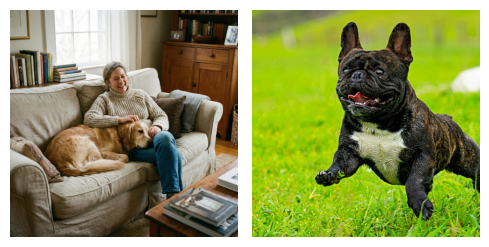

Embedding global (CLS): (768,), Patch embeddings: (2254, 768)
Embedding global (CLS): (768,), Patch embeddings: (3140, 768)

Similitud coseno: 0.027
Parecido: 2.7%
  (0% = nada que ver | 50% = algo relacionado | 100% = idénticas)


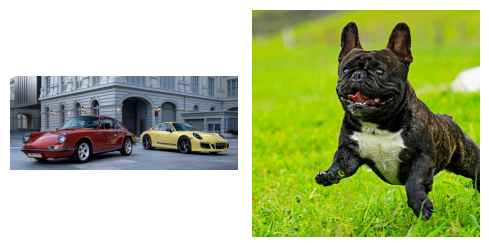

In [64]:
def compare_images(img1, img2):
    """Calcula similitud coseno entre los embeddings de las imagenes"""
    cls_1, _ = extract_embeddings(img1)
    cls_2, _ = extract_embeddings(img2)

    emb1 = cls_1.flatten()
    emb2 = cls_2.flatten()
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    similarity_percent = similarity * 100

    print(f"\nSimilitud coseno: {similarity:.3f}")
    print(f"Parecido: {similarity_percent:.1f}%")
    print(f"  (0% = nada que ver | 50% = algo relacionado | 100% = idénticas)")

    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    return similarity

    
compare_images(image_fruits, image_bananas)
compare_images(image_person_dog, image_dog);

compare_images(image_cars, image_dog);

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)


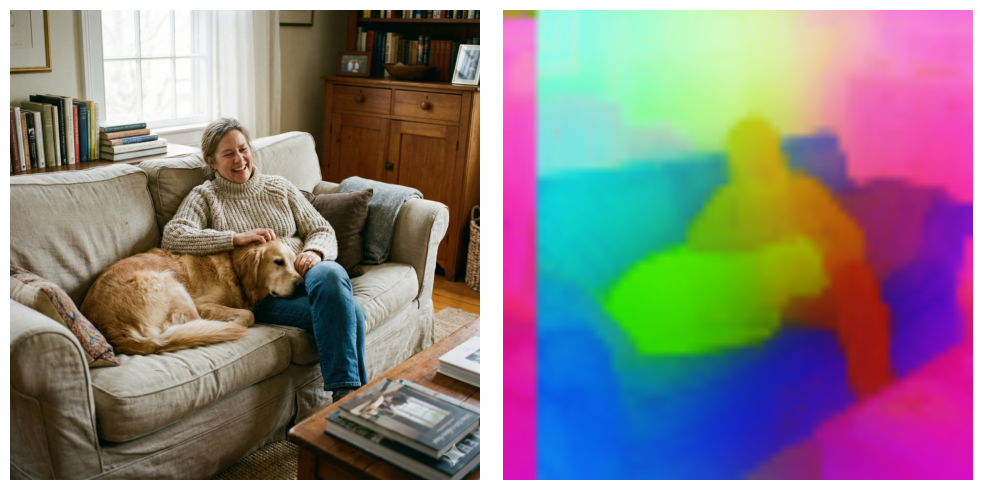

In [51]:
def visualize_embeddings(img):
    """Visualiza los embeddings de parches con colores vibrantes usando PCA + sigmoid"""
    _, patch_emb = extract_embeddings(img)

    pixel_values = processor(images=img, return_tensors="pt", do_resize=False, do_center_crop=False)["pixel_values"]
    patch_size = model.config.patch_size
    tokens_h = pixel_values.shape[-2] // patch_size
    tokens_w = pixel_values.shape[-1] // patch_size
    tokens_hw = tokens_h * tokens_w

    # PCA y transformación sigmoid para colores vibrantes
    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(patch_emb[:tokens_hw])
    pca_tensor = torch.from_numpy(pca_features).view(tokens_h, tokens_w, 3)
    img_pca_2d = torch.nn.functional.sigmoid(-pca_tensor.mul(2.0)).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[1].imshow(img_pca_2d, interpolation="bilinear")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


visualize_embeddings(image_person_dog)

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)
Embedding global (CLS): (768,), Patch embeddings: (2404, 768)


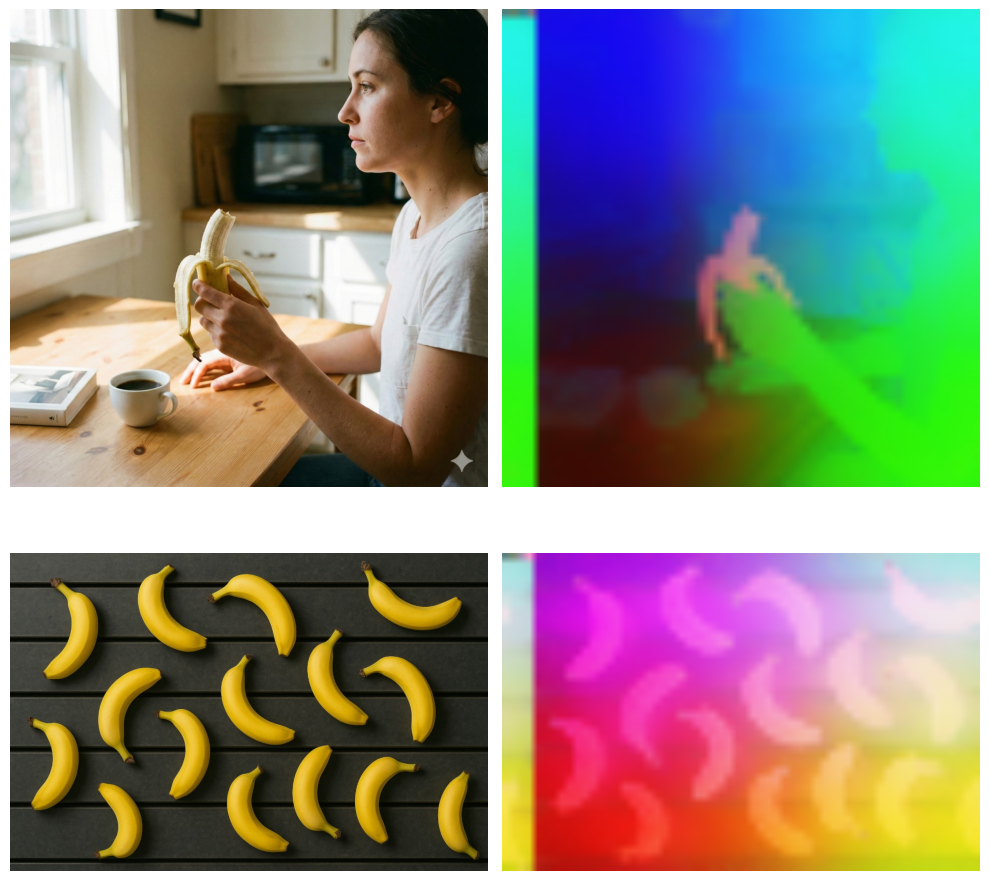

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)
Embedding global (CLS): (768,), Patch embeddings: (3140, 768)


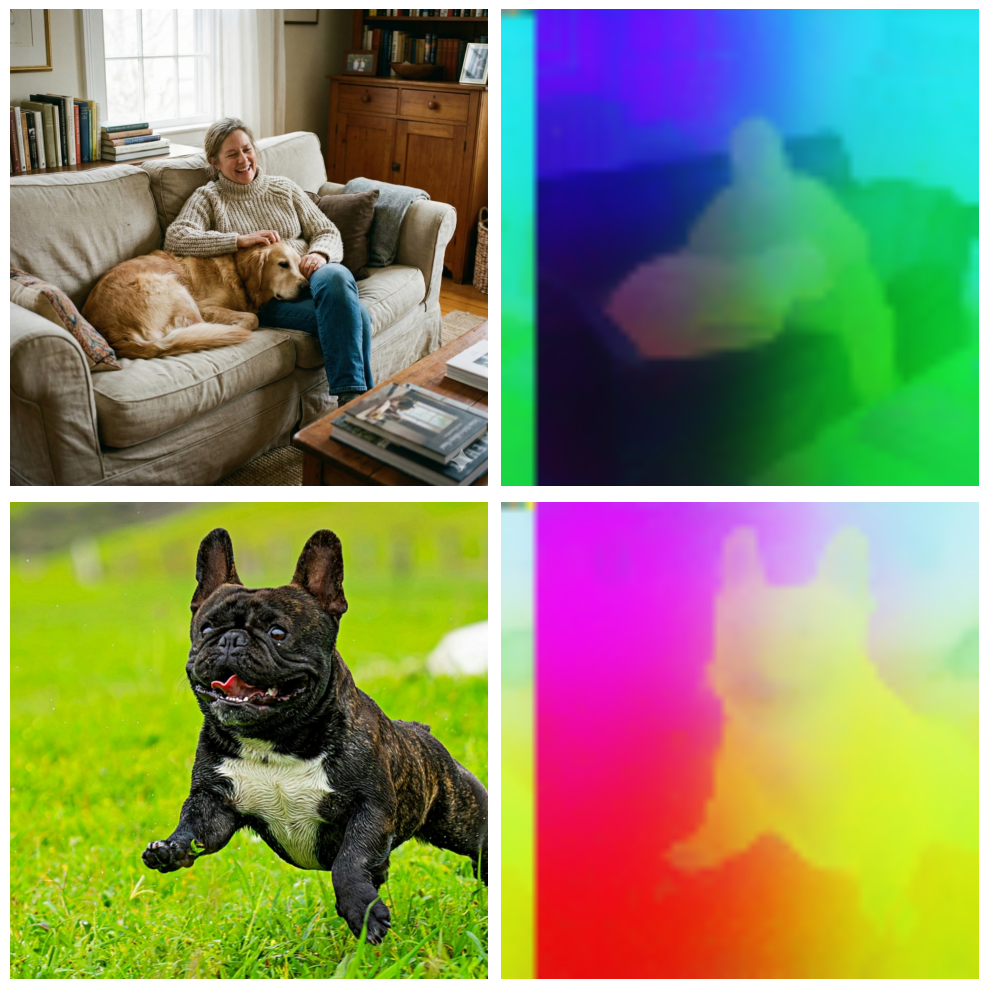

In [53]:
def visualize_embeddings_together(img1, img2):
    """Visualiza los embeddings de 2 imagenes en el mismo espacio PCA con colores vibrantes"""
    _, patch_emb_1 = extract_embeddings(img1)
    _, patch_emb_2 = extract_embeddings(img2)
    
    # Calcular dimensiones de cada imagen
    pixel_values_1 = processor(images=img1, return_tensors="pt", do_resize=False, do_center_crop=False)["pixel_values"]
    pixel_values_2 = processor(images=img2, return_tensors="pt", do_resize=False, do_center_crop=False)["pixel_values"]
    patch_size = model.config.patch_size
    
    tokens_h1 = pixel_values_1.shape[-2] // patch_size
    tokens_w1 = pixel_values_1.shape[-1] // patch_size
    tokens_hw1 = tokens_h1 * tokens_w1
    
    tokens_h2 = pixel_values_2.shape[-2] // patch_size
    tokens_w2 = pixel_values_2.shape[-1] // patch_size
    tokens_hw2 = tokens_h2 * tokens_w2
    
    # Combinar embeddings en el mismo espacio PCA
    combined = np.vstack([patch_emb_1[:tokens_hw1], patch_emb_2[:tokens_hw2]])
    
    # PCA en el espacio combinado
    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(combined)
    
    # Separar las features e invertir para que objetos centrales sean vibrantes
    pca_img1 = torch.from_numpy(pca_features[:tokens_hw1]).view(tokens_h1, tokens_w1, 3)
    pca_img2 = torch.from_numpy(pca_features[tokens_hw1:]).view(tokens_h2, tokens_w2, 3)
    
    # Invertir y aplicar sigmoid: valores cercanos a 0 -> colores vivos
    img_pca_1 = torch.nn.functional.sigmoid(-pca_img1.mul(2.0)).numpy()
    img_pca_2 = torch.nn.functional.sigmoid(-pca_img2.mul(2.0)).numpy()
    
    # Visualizar
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(img1)
    axes[0, 0].axis("off")
    axes[0, 1].imshow(img_pca_1, interpolation="bilinear")
    axes[0, 1].axis("off")
    axes[1, 0].imshow(img2)
    axes[1, 0].axis("off")
    axes[1, 1].imshow(img_pca_2, interpolation="bilinear")
    axes[1, 1].axis("off")
    plt.tight_layout()
    plt.show()
    
visualize_embeddings_together(image_person_banana, image_bananas)
visualize_embeddings_together(image_person_dog, image_dog)

## Resumen

En este notebook hemos aprendido:

✅ Que es el aprendizaje auto-supervisado  
✅ Como funciona DINOv2 como extractor de features  
✅ Extraer embeddings globales y por patches  
✅ Calcular similitud entre imagenes y regiones  
✅ Visualizar embeddings con t-SNE  
✅ Crear mapas de similitud  
✅ Aplicaciones en vision industrial  

**Siguiente paso**: En el proximo notebook veremos SAM2 para segmentacion universal y como combinarlo con Grounding DINO y Qwen2.5-VL.

**Contacto**: Si tienes dudas puedes escribirme un email!